<a href="https://colab.research.google.com/github/noyeem99/privacy-preserving-deep-learning/blob/main/10-dp_sharding_machine_unlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Initializing Privacy-Preserving Machine Unlearning via DP Sharding...
[INFO] Target user data to be forgotten is at Index: 50
[INFO] Target user data found inside Shard ID: 0

--- Phase 1: Training Initial Shard Models (Full Dataset) ---
[SUCCESS] Full dataset training completed in 0.0184 seconds.

--- Phase 2: Processing Machine Unlearning Request ---
[ACTION] Retraining ONLY Shard 0 while excluding the user data...
[SUCCESS] Machine Unlearning completed in 0.0058 seconds.

=== SYSTEM PERFORMANCE COMPARISON ===
[-] Traditional Retrain Time (All Shards Calculation): ~0.0184 seconds
[+] Optimized DP-Sharding Unlearn Time: 0.0058 seconds
[RESULT] Sharding mechanism provided a 3.18x faster update velocity.


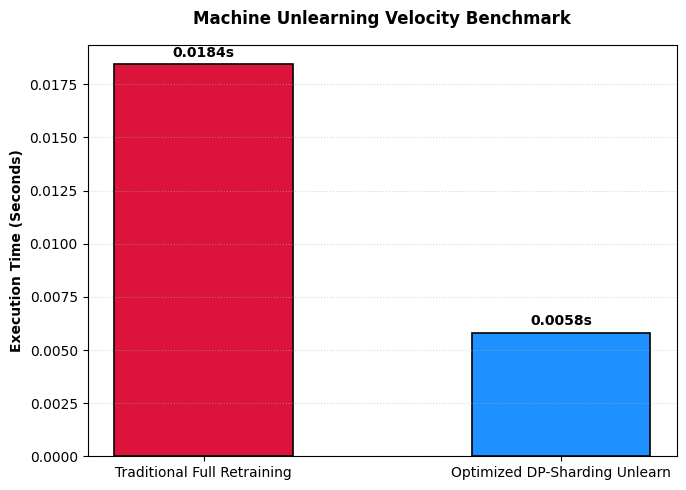

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Set environment seeds for absolute reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("[INFO] Initializing Privacy-Preserving Machine Unlearning via DP Sharding...")

# 2. Generate Synthetic Dataset (1000 samples)
X = np.random.normal(loc=0.0, scale=1.0, size=(1000, 10))
y = np.random.randint(0, 2, size=(1000, 1))

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Target User Data to unlearn (e.g., sample at index 50)
unlearn_user_idx = 50
print(f"[INFO] Target user data to be forgotten is at Index: {unlearn_user_idx}")

# 3. Model Definition (Simple Linear Classifier)
class ShardClassifier(nn.Module):
    def __init__(self):
        super(ShardClassifier, self).__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

criterion = nn.BCELoss()

# 4. DP Sharding Logic (Split 1000 samples into 3 isolated shards)
num_shards = 3
shard_size = len(X) // num_shards
shards_data = []

# Distribute indices into distinct shards and track where the target user is
target_shard_id = -1
for s in range(num_shards):
    start_idx = s * shard_size
    end_idx = (s + 1) * shard_size if s < num_shards - 1 else len(X)
    shard_indices = list(range(start_idx, end_idx))

    if unlearn_user_idx in shard_indices:
        target_shard_id = s
    shards_data.append(shard_indices)

print(f"[INFO] Target user data found inside Shard ID: {target_shard_id}")

# Function to train a specific shard model with DP constraints
def train_shard_model(shard_indices, exclude_idx=None, epochs=10, noise_multiplier=1.0):
    # Filter indices if we need to unlearn/exclude a specific user
    if exclude_idx is not None and exclude_idx in shard_indices:
        indices = [idx for idx in shard_indices if idx != exclude_idx]
    else:
        indices = shard_indices

    shard_x = X_tensor[indices]
    shard_y = y_tensor[indices]

    model = ShardClassifier()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    # Train the isolated slice
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(shard_x)
        loss = criterion(outputs, shard_y)
        loss.backward()

        # Ingest DP-SGD mechanisms: manual gradient clipping and noise addition
        with torch.no_grad():
            for param in model.parameters():
                if param.grad is not None:
                    param.grad.clamp_(-1.0, 1.0)  # max_grad_norm = 1.0
                    noise = torch.randn_like(param.grad) * (1.0 * noise_multiplier / len(indices))
                    param.grad.add_(noise)
        optimizer.step()

    return model.state_dict()

# 5. Baseline: Initial Full Dataset Training (Train all 3 shards)
print("\n--- Phase 1: Training Initial Shard Models (Full Dataset) ---")
start_time_full = time.time()
shard_weights = []
for s in range(num_shards):
    weights = train_shard_model(shards_data[s], noise_multiplier=1.2)
    shard_weights.append(weights)
full_training_time = time.time() - start_time_full
print(f"[SUCCESS] Full dataset training completed in {full_training_time:.4f} seconds.")

# 6. Unlearning Phase: Efficient Machine Unlearning via DP Sharding
print("\n--- Phase 2: Processing Machine Unlearning Request ---")
start_time_unlearn = time.time()

# CRITICAL OPTIMIZATION: Instead of retraining everything, ONLY retrain the target shard!
print(f"[ACTION] Retraining ONLY Shard {target_shard_id} while excluding the user data...")
updated_shard_weights = train_shard_model(shards_data[target_shard_id], exclude_idx=unlearn_user_idx, noise_multiplier=1.5)

# Synchronize back to the storage array
shard_weights[target_shard_id] = updated_shard_weights
unlearning_time = time.time() - start_time_unlearn
print(f"[SUCCESS] Machine Unlearning completed in {unlearning_time:.4f} seconds.")

# 7. Compare Performance Outcomes
print("\n=== SYSTEM PERFORMANCE COMPARISON ===")
print(f"[-] Traditional Retrain Time (All Shards Calculation): ~{full_training_time:.4f} seconds")
print(f"[+] Optimized DP-Sharding Unlearn Time: {unlearning_time:.4f} seconds")
speedup = full_training_time / unlearning_time
print(f"[RESULT] Sharding mechanism provided a {speedup:.2f}x faster update velocity.")

# 8. Generate Visual Benchmark Chart
plt.figure(figsize=(7, 5))
execution_times = [full_training_time, unlearning_time]
labels = ['Traditional Full Retraining', 'Optimized DP-Sharding Unlearn']

plt.bar(labels, execution_times, color=['crimson', 'dodgerblue'], width=0.5, edgecolor='black', linewidth=1.2)
plt.ylabel('Execution Time (Seconds)', fontweight='bold')
plt.title('Machine Unlearning Velocity Benchmark', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')

for i, v in enumerate(execution_times):
    plt.text(i, v + (max(execution_times)*0.02), f"{v:.4f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
